In [1]:
import sys
sys.path.insert(0, '..')
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from src.dataset import CLASS_NAMES

os.makedirs('../results', exist_ok=True)
DATA_ROOT = '../dataset'
print('Libraries loaded')

Libraries loaded


## 1. Load Preprocessed Flat Features (28×28 greyscale)

In [2]:
# HAM10000 provides pre-resized 28×28 CSV for quick baselines
csv_path = f'{DATA_ROOT}/hmnist_28_28_L.csv'
df_flat  = pd.read_csv(csv_path)

# Last column is the label (0-6)
label_col = df_flat.columns[-1]
X = df_flat.drop(columns=[label_col]).values.astype(np.float32) / 255.0
y = df_flat[label_col].values

print(f'Feature matrix: {X.shape}  |  Labels: {y.shape}')
print(f'Classes: {np.unique(y)}')
print(f'Class distribution: {pd.Series(y).value_counts().sort_index().to_dict()}')

Feature matrix: (10015, 784)  |  Labels: (10015,)
Classes: [0 1 2 3 4 5 6]
Class distribution: {0: 327, 1: 514, 2: 1099, 3: 115, 4: 6705, 5: 142, 6: 1113}


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (8012, 784)  Test: (2003, 784)


## 2. Majority Class Baseline

In [4]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

bal_acc_dummy = balanced_accuracy_score(y_test, y_pred_dummy)
acc_dummy     = (y_pred_dummy == y_test).mean()
print(f'Majority Class Baseline:')
print(f'  Accuracy:         {acc_dummy:.4f}')
print(f'  Balanced Accuracy:{bal_acc_dummy:.4f}  ← expected ~0.143 (1/7)')

Majority Class Baseline:
  Accuracy:         0.6695
  Balanced Accuracy:0.1429  ← expected ~0.143 (1/7)


## 3. Logistic Regression

In [5]:
# With PCA for speed
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=100, random_state=42)),
    ('lr',     LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=1.0, solver='saga', n_jobs=-1, random_state=42)),
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression (28×28 greyscale + PCA100):')
print(f'  Balanced Accuracy: {bal_acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr,
      target_names=[CLASS_NAMES[i] for i in sorted(np.unique(y_test))]))

Logistic Regression (28×28 greyscale + PCA100):
  Balanced Accuracy: 0.3176

              precision    recall  f1-score   support

       akiec       0.11      0.31      0.17        65
         bcc       0.18      0.30      0.22       103
         bkl       0.28      0.32      0.30       220
          df       0.04      0.26      0.07        23
         mel       0.84      0.39      0.53      1341
          nv       0.03      0.29      0.05        28
        vasc       0.25      0.35      0.30       223

    accuracy                           0.37      2003
   macro avg       0.25      0.32      0.23      2003
weighted avg       0.64      0.37      0.44      2003



## 4. Random Forest with HOG Features

In [6]:
from skimage.feature import hog as skimage_hog

def extract_hog(X_flat, img_size=28):
    """Extract HOG features from flat greyscale images."""
    features = []
    for row in X_flat:
        img = row.reshape(img_size, img_size)
        feat = skimage_hog(img, orientations=9, pixels_per_cell=(4,4),
                           cells_per_block=(2,2), feature_vector=True)
        features.append(feat)
    return np.array(features)

print('Extracting HOG features...')
X_train_hog = extract_hog(X_train)
X_test_hog  = extract_hog(X_test)
print(f'HOG feature dim: {X_train_hog.shape[1]}')

Extracting HOG features...
HOG feature dim: 1296


In [7]:
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    max_depth=20, n_jobs=-1, random_state=42
)
rf.fit(X_train_hog, y_train)
y_pred_rf = rf.predict(X_test_hog)

bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
print(f'Random Forest (HOG features):')
print(f'  Balanced Accuracy: {bal_acc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf,
      target_names=[CLASS_NAMES[i] for i in sorted(np.unique(y_test))]))

Random Forest (HOG features):
  Balanced Accuracy: 0.1429

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        65
         bcc       0.00      0.00      0.00       103
         bkl       0.00      0.00      0.00       220
          df       0.00      0.00      0.00        23
         mel       0.67      1.00      0.80      1341
          nv       0.00      0.00      0.00        28
        vasc       0.00      0.00      0.00       223

    accuracy                           0.67      2003
   macro avg       0.10      0.14      0.11      2003
weighted avg       0.45      0.67      0.54      2003



d:\Code\envs\pytorch_gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\envs\pytorch_gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Code\envs\pytorch_gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Simple CNN (3-Layer)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# DataLoaders from CSV
X_tr_cnn = torch.tensor(X_train.reshape(-1, 1, 28, 28))
X_te_cnn = torch.tensor(X_test.reshape(-1, 1, 28, 28))
y_tr_t   = torch.tensor(y_train, dtype=torch.long)
y_te_t   = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_tr_cnn, y_tr_t)
test_ds  = TensorDataset(X_te_cnn, y_te_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=128)

cnn_model = SimpleCNN(7).to(DEVICE)
optimizer_cnn = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
print(f'Simple CNN params: {sum(p.numel() for p in cnn_model.parameters()):,}')

Simple CNN params: 390,087


In [9]:
from sklearn.metrics import balanced_accuracy_score

NUM_EPOCHS = 20
train_losses, test_bal_accs = [], []

for epoch in range(NUM_EPOCHS):
    cnn_model.train()
    epoch_loss = 0.0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_cnn.zero_grad()
        loss = nn.CrossEntropyLoss()(cnn_model(Xb), yb)
        loss.backward()
        optimizer_cnn.step()
        epoch_loss += loss.item()

    # Quick eval every 5 epochs
    if (epoch + 1) % 5 == 0:
        cnn_model.eval()
        all_preds = []
        with torch.no_grad():
            for Xb, _ in test_dl:
                preds = cnn_model(Xb.to(DEVICE)).argmax(dim=1).cpu()
                all_preds.extend(preds.numpy())
        ba = balanced_accuracy_score(y_test, all_preds)
        print(f'Epoch {epoch+1:3d} | Loss: {epoch_loss/len(train_dl):.4f} | Test Bal Acc: {ba:.4f}')
        test_bal_accs.append(ba)
    train_losses.append(epoch_loss / len(train_dl))

Epoch   5 | Loss: 0.8032 | Test Bal Acc: 0.3548
Epoch  10 | Loss: 0.7307 | Test Bal Acc: 0.3499
Epoch  15 | Loss: 0.6192 | Test Bal Acc: 0.3178
Epoch  20 | Loss: 0.4039 | Test Bal Acc: 0.3344


## 6. Baseline Comparison Chart

                     Model  Balanced Acc                 Notes
 Majority Class (baseline)      0.142857      Trivial baseline
       Random Forest + HOG      0.142857 Hand-crafted features
 Logistic Regression + PCA      0.317570       28×28 greyscale
       Simple CNN (3 conv)      0.334358 28×28 grey, 20 epochs
EfficientNet-B4 (expected)      0.830000           Notebook 02
       Ensemble (expected)      0.860000           Notebook 03


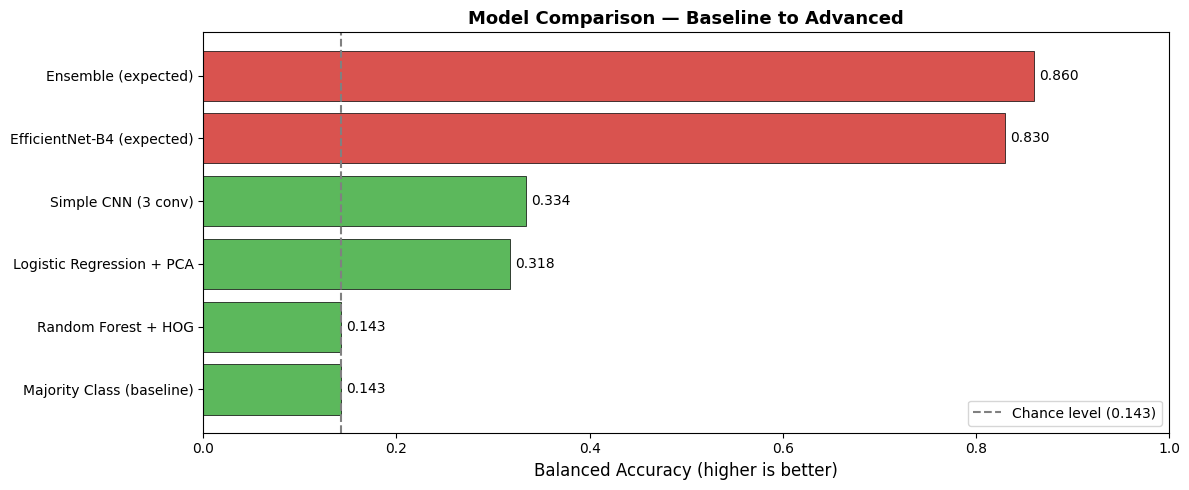

In [10]:
# Final CNN evaluation
cnn_model.eval()
all_preds_cnn = []
with torch.no_grad():
    for Xb, _ in test_dl:
        all_preds_cnn.extend(cnn_model(Xb.to(DEVICE)).argmax(dim=1).cpu().numpy())
bal_acc_cnn = balanced_accuracy_score(y_test, all_preds_cnn)

# Summary
results = pd.DataFrame([
    {'Model': 'Majority Class (baseline)',          'Balanced Acc': bal_acc_dummy, 'Notes': 'Trivial baseline'},
    {'Model': 'Logistic Regression + PCA',          'Balanced Acc': bal_acc_lr,    'Notes': '28×28 greyscale'},
    {'Model': 'Random Forest + HOG',                'Balanced Acc': bal_acc_rf,    'Notes': 'Hand-crafted features'},
    {'Model': 'Simple CNN (3 conv)',                 'Balanced Acc': bal_acc_cnn,   'Notes': '28×28 grey, 20 epochs'},
    {'Model': 'EfficientNet-B4 (expected)',          'Balanced Acc': 0.83,          'Notes': 'Notebook 02'},
    {'Model': 'Ensemble (expected)',                 'Balanced Acc': 0.86,          'Notes': 'Notebook 03'},
]).sort_values('Balanced Acc', ascending=True)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d9534f' if 'expected' in n else '#5cb85c' for n in results['Model']]
bars = ax.barh(results['Model'], results['Balanced Acc'], color=colors,
               edgecolor='black', linewidth=0.5)
ax.axvline(1/7, color='grey', linestyle='--', linewidth=1.5,
            label='Chance level (0.143)')
for bar, val in zip(bars, results['Balanced Acc']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Balanced Accuracy (higher is better)', fontsize=12)
ax.set_title('Model Comparison — Baseline to Advanced', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', bbox_inches='tight', dpi=150)
plt.show()